# Logistic Regression Baseline Model for GSR Classification

This notebook builds a baseline logistic regression model to classify particles as **GSR (1)** or **Non-GSR (0)** using engineered features.

The workflow includes:
- Data loading and inspection
- Target cleaning and encoding
- Feature matrix construction
- Group-aware train/test split
- Model training using a pipeline
- Performance evaluation (confusion matrix, classification report, ROC AUC)
- Model interpretability via feature coefficients

A group-based split is used to prevent **stub-level leakage**, ensuring realistic model evaluation.

In [2]:
import pandas as pd
import numpy as np

# Load dataset
df = pd.read_parquet("../../../data/processed/particle_labeled.parquet")

# Inspect structure
print("Shape:", df.shape)
print("\nColumns:\n", df.columns.tolist())

df.head()

Shape: (2801667, 95)

Columns:
 ['stub_id', 'particle_id', 'relevance_class', 'ac', 'ag', 'al', 'ar', 'as', 'at', 'au', 'b', 'ba', 'bi', 'br', 'ca', 'cd', 'ce', 'cl', 'co', 'cr', 'cs', 'cu', 'dy', 'er', 'eu', 'f', 'fe', 'fr', 'ga', 'gd', 'ge', 'hf', 'hg', 'ho', 'i', 'in', 'ir', 'k', 'kr', 'la', 'lu', 'mg', 'mn', 'mo', 'n', 'na', 'nb', 'nd', 'ne', 'ni', 'np', 'o', 'os', 'p', 'pa', 'pb', 'pd', 'pm', 'po', 'pr', 'pt', 'pu', 'ra', 'rb', 're', 'rh', 'rn', 'ru', 's', 'sb', 'sc', 'se', 'si', 'sm', 'sn', 'sr', 'ta', 'tb', 'tc', 'te', 'th', 'ti', 'tl', 'tm', 'u', 'v', 'w', 'xe', 'y', 'yb', 'zn', 'zr', 'merged_relevance_class', 'final_class', 'label']


,stub_id,particle_id,relevance_class,ac,ag,al,ar,as,at,au,...,v,w,xe,y,yb,zn,zr,merged_relevance_class,final_class,label
0,22,1454,PbSb,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,PbSb,PbSb,GSR
1,22,1274,PbSbBa,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,PbSbBa,PbBaSb,GSR
2,22,275,PbSbBa,0.0,0.0,0.751013,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,PbSbBa,PbBaSb,GSR
3,22,714,PbSbBa,0.0,0.0,0.824510,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,PbSbBa,PbBaSb,GSR
4,22,2887,PbSb,0.0,0.0,0.000000,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,PbSb,PbSb,GSR


## Target Cleaning and Filtering

The dataset contains three labels: **GSR**, **Non_GSR**, and **Ambiguous**.  
For this baseline model, we restrict the analysis to binary classification by removing ambiguous observations.

The target variable is encoded as:
- GSR → 1
- Non_GSR → 0

In [3]:
# Filter to binary labels
df = df[df["label"].isin(["GSR", "Non_GSR"])].copy()

# Encode target
df["target"] = df["label"].map({
    "GSR": 1,
    "Non_GSR": 0
})

# Check class balance
print(df["target"].value_counts())

target
0    1216039
1    1078946
Name: count, dtype: int64


## Feature Matrix Construction

Predictor variables were restricted to numeric elemental composition features derived from particle measurements. Identifier fields and target-related variables were excluded to prevent data leakage.

During initial modeling, several elemental features—particularly lead (Pb), antimony (Sb), and barium (Ba)—were identified as dominant predictors that nearly perfectly separated the target classes. These elements are strongly associated with GSR classification and therefore introduce a form of implicit label reconstruction.

To evaluate the impact of these dominant predictors, two feature sets were constructed:

- **Original Feature Set:** Includes all numeric elemental variables, allowing the model to fully leverage the strongest known GSR indicators.
- **Reduced Feature Set:** Removes Pb, Sb, and Ba to encourage the model to learn broader multi-element relationships and produce a more realistic baseline.

This dual approach enables direct comparison between a near-deterministic model and a more generalized classification model.

In [4]:
# Define columns to exclude from modeling
exclude_cols = ["label", "target", "stub_id", "particle_id"]

# Keep only numeric candidate predictors
candidate_cols = [col for col in df.columns if col not in exclude_cols]

numeric_cols = [
    col for col in candidate_cols
    if pd.api.types.is_numeric_dtype(df[col])
]

# ------------------------------------------------------------
# Original model feature set: includes all numeric elements
# ------------------------------------------------------------
original_feature_cols = numeric_cols.copy()

X_original = df[original_feature_cols].copy()
y_original = df["target"]
groups_original = df["stub_id"]

print("Original feature count:", len(original_feature_cols))
print("Original model includes:", [c for c in ["pb", "sb", "ba"] if c in original_feature_cols])


# ------------------------------------------------------------
# Reduced model feature set: removes dominant Pb, Sb, Ba signals
# ------------------------------------------------------------
direct_signal_cols = ["pb", "sb", "ba"]

feature_cols = [
    col for col in numeric_cols
    if col not in direct_signal_cols
]

X = df[feature_cols].copy()
y = df["target"]
groups = df["stub_id"]

print("Reduced feature count:", len(feature_cols))
print("Removed features:", [c for c in direct_signal_cols if c in numeric_cols])

Original feature count: 89
Original model includes: ['pb', 'sb', 'ba']
Reduced feature count: 86
Removed features: ['pb', 'sb', 'ba']


## Train/Test Split (Group-Aware)

To avoid leakage, the dataset is split using `stub_id` as the grouping variable. This ensures that particles from the same stub do not appear in both training and test sets.

This step is critical because particles within a stub may share underlying structure that could artificially inflate model performance if not properly separated.

A single group-aware split is applied and reused for both the original and reduced feature sets. This ensures that both models are evaluated on identical training and test observations, allowing for a fair and consistent comparison of performance.

To improve computational efficiency, model training is performed on a sampled subset of the training data while evaluation is conducted on the full test set.

In [5]:
from sklearn.model_selection import GroupShuffleSplit

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=42
)

# Use one shared group-aware split so both models are compared fairly
train_idx, test_idx = next(gss.split(X, y, groups))

# Reduced model split
X_train = X.iloc[train_idx].copy()
X_test = X.iloc[test_idx].copy()
y_train = y.iloc[train_idx].copy()
y_test = y.iloc[test_idx].copy()

# Original model split using the same train/test row positions
X_train_original = X_original.iloc[train_idx].copy()
X_test_original = X_original.iloc[test_idx].copy()
y_train_original = y_original.iloc[train_idx].copy()
y_test_original = y_original.iloc[test_idx].copy()

print("Reduced train shape:", X_train.shape)
print("Reduced test shape:", X_test.shape)

print("Original train shape:", X_train_original.shape)
print("Original test shape:", X_test_original.shape)

# Optional sampling for faster training
train_sample_n = 250000

if len(X_train) > train_sample_n:
    sample_idx = X_train.sample(n=train_sample_n, random_state=42).index
    
    X_train_fit = X_train.loc[sample_idx].copy()
    y_train_fit = y_train.loc[sample_idx].copy()
    
    X_train_original_fit = X_train_original.loc[sample_idx].copy()
    y_train_original_fit = y_train_original.loc[sample_idx].copy()
else:
    X_train_fit = X_train.copy()
    y_train_fit = y_train.copy()
    
    X_train_original_fit = X_train_original.copy()
    y_train_original_fit = y_train_original.copy()

print("Reduced training rows used for fitting:", len(X_train_fit))
print("Original training rows used for fitting:", len(X_train_original_fit))

Reduced train shape: (1851761, 86)
Reduced test shape: (443224, 86)
Original train shape: (1851761, 89)
Original test shape: (443224, 89)
Reduced training rows used for fitting: 250000
Original training rows used for fitting: 250000


## Logistic Regression Pipeline

Two logistic regression models were developed using identical preprocessing pipelines, consisting of median imputation, feature standardization, and L2-regularized logistic regression.

- **Reduced Model:** Trained on the feature set with Pb, Sb, and Ba removed
- **Original Model:** Trained on the full feature set including all elemental variables

Both models use the same hyperparameters and training procedure to ensure that differences in performance are attributable solely to the inclusion or exclusion of dominant elemental predictors.

This design allows for a controlled comparison between a model that relies heavily on strong GSR indicators and one that must infer classification from broader compositional patterns.

In [6]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

# Reduced model pipeline: Pb, Sb, and Ba removed
pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        solver="lbfgs",
        C=0.5,
        max_iter=300,
        class_weight="balanced",
        random_state=42
    ))
])

pipeline.fit(X_train_fit, y_train_fit)


# Original model pipeline: all numeric elemental features included
original_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(
        solver="lbfgs",
        C=0.5,
        max_iter=300,
        class_weight="balanced",
        random_state=42
    ))
])

original_pipeline.fit(X_train_original_fit, y_train_original_fit)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('scaler', ...), ...]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. I

## Model Evaluation

Model performance was evaluated using:

- Confusion Matrix
- Classification Report (precision, recall, F1-score)
- ROC AUC score
- Precision-Recall AUC

These metrics provide a comprehensive view of classification performance across both models.

The **reduced model** demonstrates strong but more realistic performance, with a ROC AUC of approximately 0.90. In contrast, the **original model**, which includes Pb, Sb, and Ba, achieves near-perfect classification performance, with a ROC AUC approaching 1.0.

This difference highlights the extent to which a small number of highly predictive elemental features can dominate model behavior and artificially inflate performance metrics.

In [7]:
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    average_precision_score
)

# Reduced model predictions
y_pred = pipeline.predict(X_test)
y_proba = pipeline.predict_proba(X_test)[:, 1]

roc_auc = roc_auc_score(y_test, y_proba)
pr_auc = average_precision_score(y_test, y_proba)

print("Reduced Model: Without Pb, Sb, Ba")
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

print("\nClassification Report:")
print(classification_report(y_test, y_pred, digits=4))

print(f"\nReduced Model ROC AUC: {roc_auc:.4f}")
print(f"Reduced Model PR AUC: {pr_auc:.4f}")


# Original model predictions
y_pred_original = original_pipeline.predict(X_test_original)
y_proba_original = original_pipeline.predict_proba(X_test_original)[:, 1]

roc_auc_original = roc_auc_score(y_test_original, y_proba_original)
pr_auc_original = average_precision_score(y_test_original, y_proba_original)

print("\n" + "-"*60)
print("Original Model: With Pb, Sb, Ba Included")
print("Confusion Matrix:")
print(confusion_matrix(y_test_original, y_pred_original))

print("\nClassification Report:")
print(classification_report(y_test_original, y_pred_original, digits=4))

print(f"\nOriginal Model ROC AUC: {roc_auc_original:.4f}")
print(f"Original Model PR AUC: {pr_auc_original:.4f}")

Reduced Model: Without Pb, Sb, Ba
Confusion Matrix:
[[185456  47819]
 [ 32159 177790]]

Classification Report:
              precision    recall  f1-score   support

           0     0.8522    0.7950    0.8226    233275
           1     0.7880    0.8468    0.8164    209949

    accuracy                         0.8196    443224
   macro avg     0.8201    0.8209    0.8195    443224
weighted avg     0.8218    0.8196    0.8197    443224


Reduced Model ROC AUC: 0.9006
Reduced Model PR AUC: 0.8799

------------------------------------------------------------
Original Model: With Pb, Sb, Ba Included
Confusion Matrix:
[[232744    531]
 [  3416 206533]]

Classification Report:
              precision    recall  f1-score   support

           0     0.9855    0.9977    0.9916    233275
           1     0.9974    0.9837    0.9905    209949

    accuracy                         0.9911    443224
   macro avg     0.9915    0.9907    0.9911    443224
weighted avg     0.9912    0.9911    0.9911    443

## ROC Curve

The ROC curve visualizes the tradeoff between true positive rate and false positive rate across different classification thresholds.

A comparison between the original and reduced models illustrates a clear distinction in performance:

- The **original model** achieves near-perfect separation, with an ROC curve that closely follows the top-left boundary of the plot.
- The **reduced model** shows strong but less extreme performance, reflecting a more realistic classification scenario.

This comparison reinforces the importance of evaluating model robustness beyond raw performance metrics.

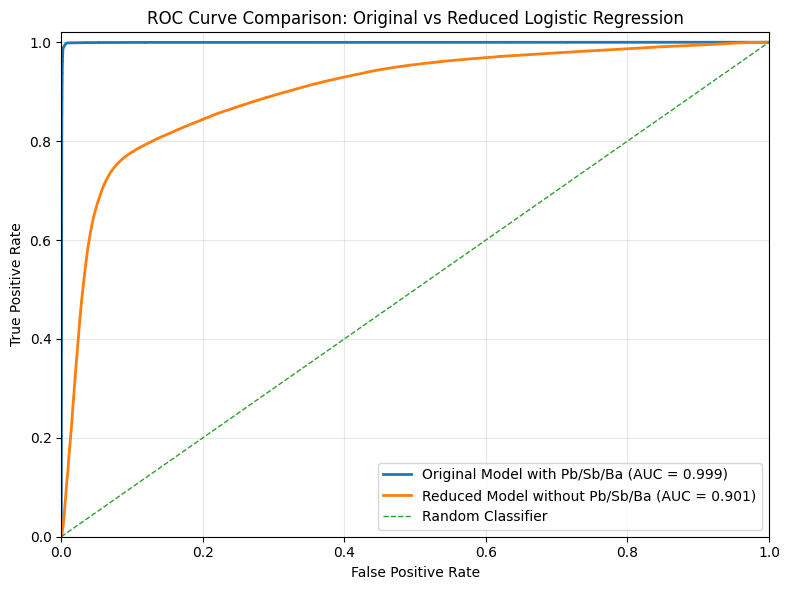

In [8]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve

fpr_original, tpr_original, _ = roc_curve(y_test_original, y_proba_original)
fpr_reduced, tpr_reduced, _ = roc_curve(y_test, y_proba)

plt.figure(figsize=(8, 6))

plt.plot(
    fpr_original,
    tpr_original,
    linewidth=2,
    label=f"Original Model with Pb/Sb/Ba (AUC = {roc_auc_original:.3f})"
)

plt.plot(
    fpr_reduced,
    tpr_reduced,
    linewidth=2,
    label=f"Reduced Model without Pb/Sb/Ba (AUC = {roc_auc:.3f})"
)

plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    linewidth=1,
    label="Random Classifier"
)

plt.xlim(0, 1)
plt.ylim(0, 1.02)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison: Original vs Reduced Logistic Regression")
plt.legend(loc="lower right")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## ROC Curve Interpretation

The comparison between the original and reduced ROC curves highlights the impact of dominant elemental predictors on model performance.

The original model, which includes Pb, Sb, and Ba, achieves near-perfect classification performance, indicating that these elements alone can almost entirely determine GSR classification. While this result demonstrates strong predictive signal, it also suggests that the model may be relying on a limited set of features that effectively encode the target variable.

In contrast, the reduced model achieves a ROC AUC of approximately 0.90, reflecting strong but more realistic performance after removing these dominant predictors. The curve shows a steep initial rise, indicating effective identification of GSR particles at low false positive rates, followed by a gradual flattening as classification becomes more challenging.

This behavior suggests that the reduced model is capturing meaningful compositional patterns rather than relying on near-deterministic rules. As a result, it provides a more interpretable and generalizable baseline for real-world forensic applications.

## Precision-Recall Curve

The Precision-Recall curve provides additional insight into model performance, particularly in scenarios where class imbalance may affect evaluation.

The original model maintains extremely high precision across nearly all recall levels, further confirming its near-deterministic behavior driven by dominant elemental features.

The reduced model demonstrates a more gradual tradeoff between precision and recall, indicating that classification decisions are based on more nuanced, multi-element patterns rather than a small set of highly predictive variables.

This behavior supports the validity of the reduced model as a more realistic baseline for GSR classification.

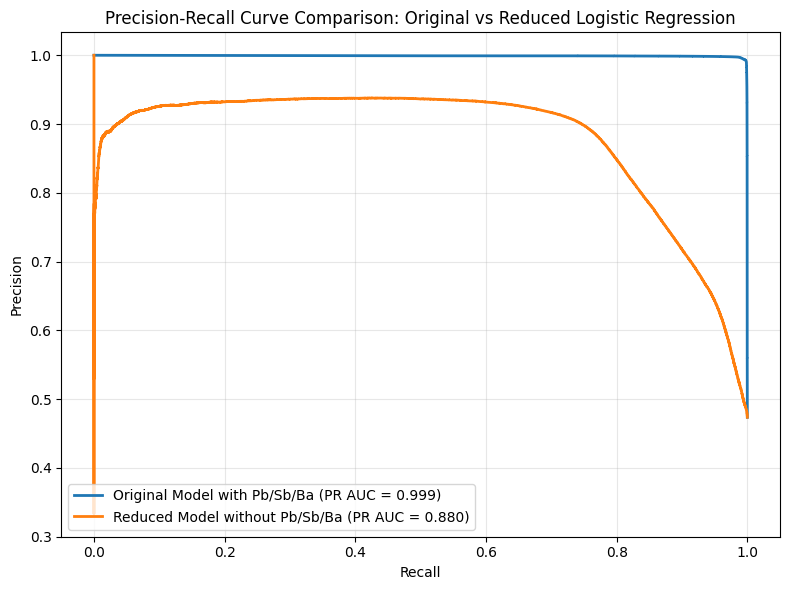

In [9]:
from sklearn.metrics import precision_recall_curve

precision_original, recall_original, _ = precision_recall_curve(
    y_test_original,
    y_proba_original
)

precision_reduced, recall_reduced, _ = precision_recall_curve(
    y_test,
    y_proba
)

plt.figure(figsize=(8, 6))

plt.plot(
    recall_original,
    precision_original,
    linewidth=2,
    label=f"Original Model with Pb/Sb/Ba (PR AUC = {pr_auc_original:.3f})"
)

plt.plot(
    recall_reduced,
    precision_reduced,
    linewidth=2,
    label=f"Reduced Model without Pb/Sb/Ba (PR AUC = {pr_auc:.3f})"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve Comparison: Original vs Reduced Logistic Regression")
plt.legend(loc="lower left")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## Feature Importance and Interpretability

Logistic regression coefficients indicate the direction and magnitude of each feature’s influence on the probability of a particle being classified as GSR.

In the original model, Pb, Sb, and Ba exhibit extremely large coefficient magnitudes, confirming their role as dominant predictors. These features effectively drive the model’s near-perfect performance by acting as strong indicators of GSR classification.

In contrast, the reduced model distributes importance across a wider set of elemental features, such as tungsten (W), iron (Fe), zinc (Zn), and sulfur (S). These features contribute more moderately to predictions and reflect broader compositional differences between GSR and non-GSR particles.

The shift from a small number of dominant predictors to a more balanced set of features supports the conclusion that the reduced model is leveraging more generalizable chemical patterns rather than relying on deterministic signals.

In [10]:
# Original model coefficients
original_coefficients = original_pipeline.named_steps["model"].coef_[0]

original_feature_importance = pd.DataFrame({
    "feature": original_feature_cols,
    "coefficient": original_coefficients
})

original_feature_importance["abs_coef"] = original_feature_importance["coefficient"].abs()

original_feature_importance = original_feature_importance.sort_values(
    by="abs_coef",
    ascending=False
)

print("Top 15 Original Model Coefficients:")
display(original_feature_importance.head(15))


# Reduced model coefficients
reduced_coefficients = pipeline.named_steps["model"].coef_[0]

reduced_feature_importance = pd.DataFrame({
    "feature": feature_cols,
    "coefficient": reduced_coefficients
})

reduced_feature_importance["abs_coef"] = reduced_feature_importance["coefficient"].abs()

reduced_feature_importance = reduced_feature_importance.sort_values(
    by="abs_coef",
    ascending=False
)

print("Top 15 Reduced Model Coefficients:")
display(reduced_feature_importance.head(15))

Top 15 Original Model Coefficients:


,feature,coefficient,abs_coef
52,pb,23.045239,23.045239
66,sb,12.290677,12.290677
23,fe,-4.656458,4.656458
8,ba,-4.535576,4.535576
18,cu,-4.002127,4.002127
48,o,-3.970287,3.970287
29,hg,-3.949162,3.949162
87,zn,-3.385957,3.385957
26,gd,-3.117844,3.117844
65,s,-1.627697,1.627697


Top 15 Reduced Model Coefficients:


,feature,coefficient,abs_coef
80,w,-2.641683,2.641683
22,fe,-1.818156,1.818156
84,zn,-1.647419,1.647419
63,s,-1.358866,1.358866
47,o,-0.887540,0.887540
17,cu,-0.834088,0.834088
25,gd,-0.804775,0.804775
24,ga,-0.793823,0.793823
2,al,-0.786109,0.786109
66,si,-0.585391,0.585391


## Model Performance Summary

The logistic regression analysis demonstrates a clear distinction between model performance when dominant elemental predictors are included versus removed.

The original model achieves near-perfect classification performance, with ROC AUC approaching 1.0 and Precision-Recall AUC near 1.0. While this reflects strong predictive capability, it is largely driven by a small number of highly informative features.

After removing Pb, Sb, and Ba, the reduced model achieves a ROC AUC of approximately 0.90 and maintains strong precision and recall across both classes. This indicates that meaningful predictive structure exists in the dataset beyond the most obvious GSR indicators.

Overall, the reduced model provides a more realistic and interpretable baseline, demonstrating that classification can be effectively performed using broader elemental patterns rather than relying solely on dominant features.